In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

In [3]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

transactions = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_cleaned.csv"
)

In [4]:
print(nav.shape)
print(transactions.shape)
print(performance.shape)

(46000, 3)
(32778, 13)
(40, 19)


In [5]:
nav["amfi_code"].nunique()

40

In [6]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
nav["date"] = pd.to_datetime(nav["date"])

In [8]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

In [ ]:
fig.write_image("../reports/nav_trend.png")

In [10]:
type(fig)

plotly.graph_objs._figure.Figure

In [ ]:
#TASK 2 

In [11]:
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [12]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [13]:
fund_aum = (
    performance
    .groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fund_aum.head()

,fund_house,aum_crore
0,Nippon India MF,154328
1,Kotak Mahindra MF,145689
2,ICICI Prudential MF,120241
3,DSP Mutual Fund,114787
4,Aditya Birla Sun Life MF,104108


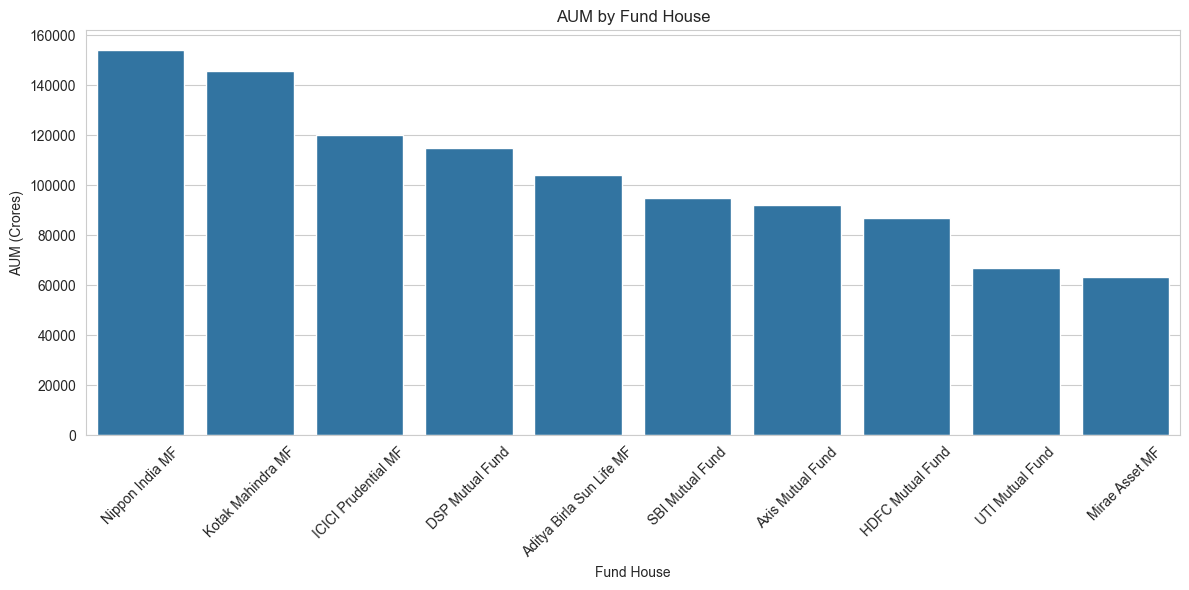

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=fund_aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=45)

plt.title("AUM by Fund House")

plt.xlabel("Fund House")
plt.ylabel("AUM (Crores)")

plt.tight_layout()

plt.show()

In [15]:
plt.savefig(
    "../reports/aum_growth.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [16]:
sip = transactions[
    transactions["transaction_type"]=="SIP"
]

sip["transaction_date"] = pd.to_datetime(
    sip["transaction_date"]
)

monthly_sip = sip.groupby(

sip["transaction_date"].dt.to_period("M")

)["amount_inr"].sum()

monthly_sip.index = monthly_sip.index.astype(str)

monthly_sip.head()

C:\Users\ankur\AppData\Local\Temp\ipykernel_32152\1999380452.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sip["transaction_date"] = pd.to_datetime(


transaction_date
2024-01    12635349
2024-02    12613376
2024-03    12088413
2024-04    13512385
2024-05    13218606
Name: amount_inr, dtype: int64

In [17]:
import plotly.express as px

fig = px.line(

x=monthly_sip.index,

y=monthly_sip.values,

title="Monthly SIP Trend"

)

fig.show()

In [18]:
fig.write_image(
"../reports/sip_trend.png"
)

In [19]:
fund_aum = (
    performance
    .groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

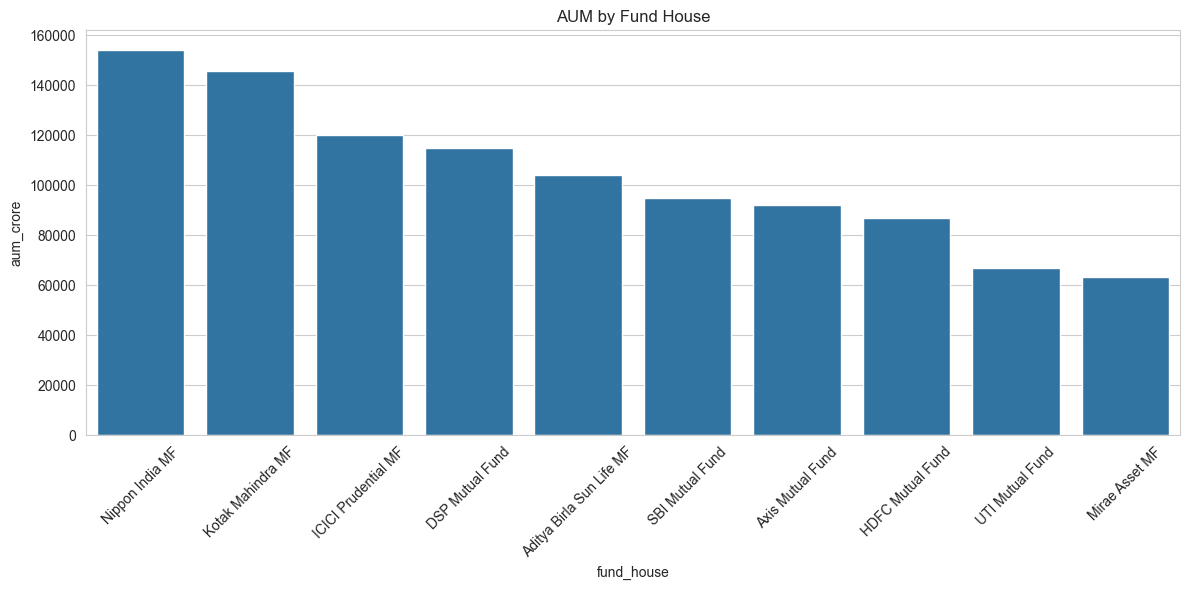

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=fund_aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=45)

plt.title("AUM by Fund House")

plt.tight_layout()

plt.show()

In [21]:
plt.savefig("../reports/aum_growth.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

TASK 4

In [22]:
category = pd.read_csv(
    "../data/raw/category_inflows.csv"
)

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [23]:
category.columns.tolist()

['month', 'category', 'net_inflow_crore']

In [25]:
pivot = category.pivot_table(

    index="category",

    columns="month",

    values="net_inflow_crore",

    aggfunc="sum"

)

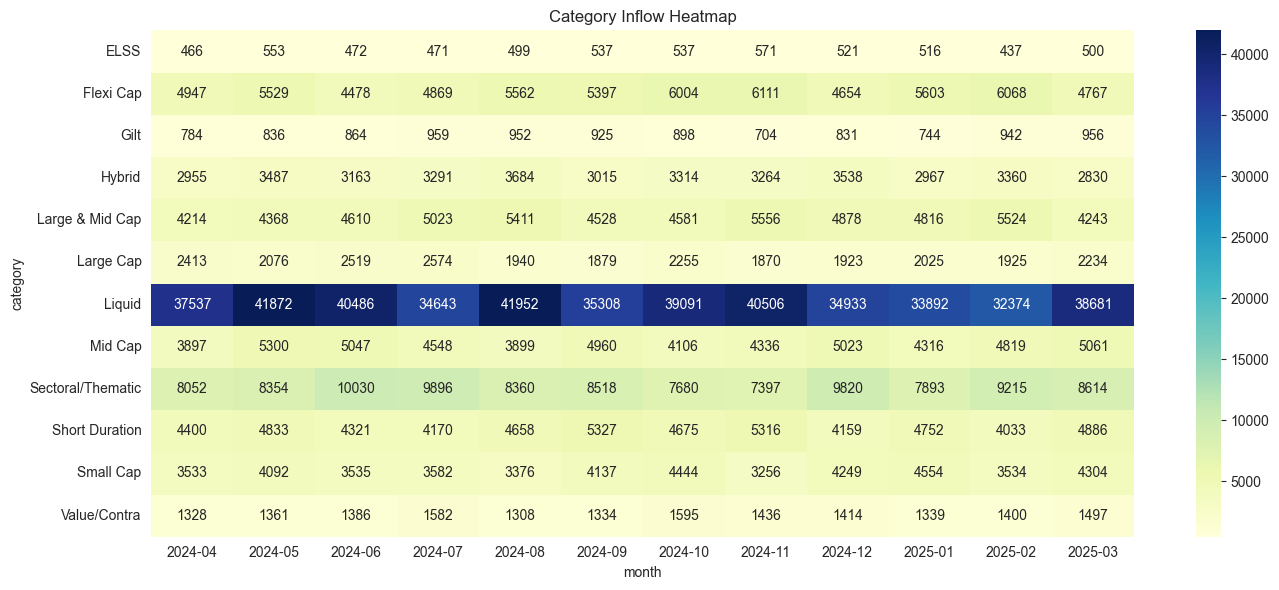

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.tight_layout()

plt.show()

In [27]:
plt.savefig(
    "../reports/category_heatmap.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

TASK 5 

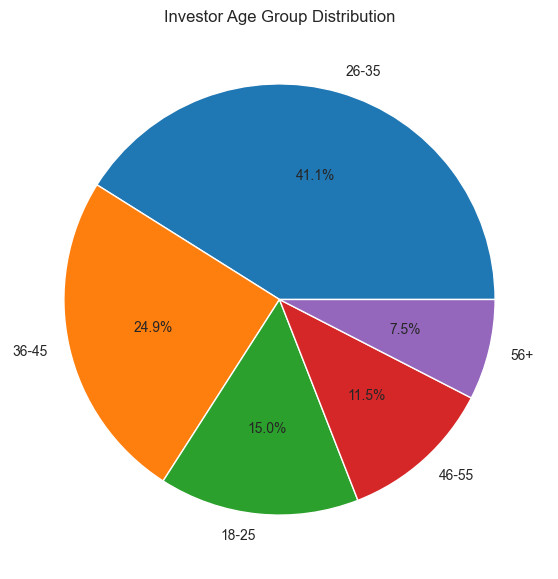

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.ylabel("")

plt.show()

In [29]:
plt.savefig(
    "../reports/age_group_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

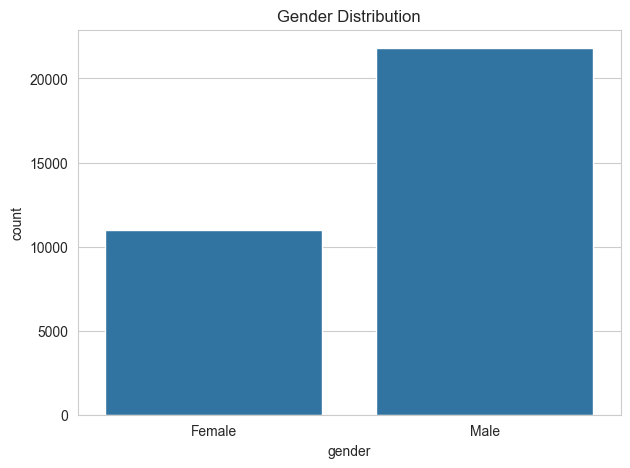

In [30]:
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

In [31]:
plt.savefig(
    "../reports/gender_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

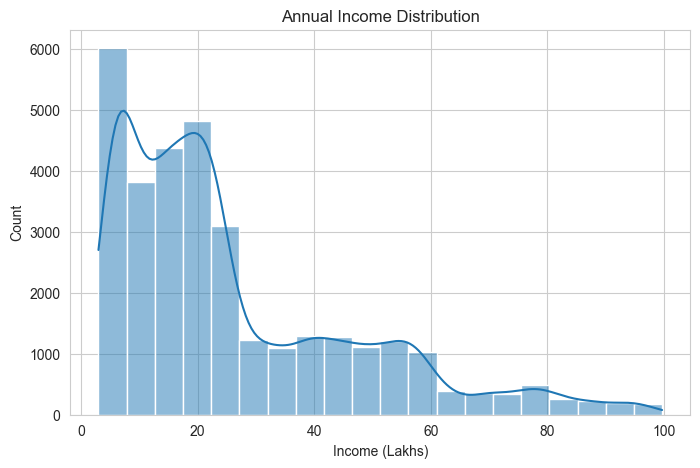

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    transactions["annual_income_lakh"],
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")

plt.xlabel("Income (Lakhs)")

plt.show()

In [33]:
plt.savefig(
    "../reports/income_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

TASK 06

In [34]:
state_sip = transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values()

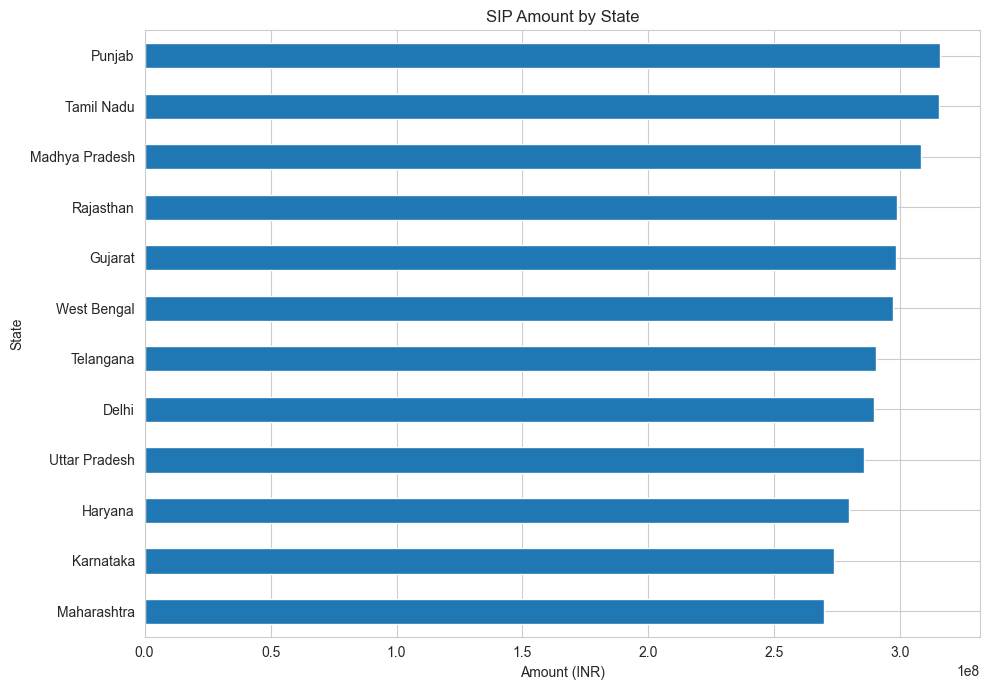

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

state_sip.plot(
    kind="barh"
)

plt.title("SIP Amount by State")

plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

In [36]:
plt.savefig(
    "../reports/state_sip_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

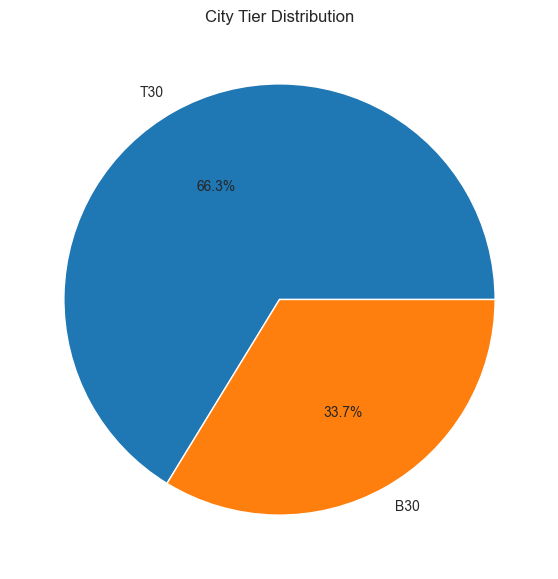

In [37]:
plt.figure(figsize=(7,7))

transactions["city_tier"].value_counts().plot(

    kind="pie",

    autopct="%1.1f%%"

)

plt.title("City Tier Distribution")

plt.ylabel("")

plt.show()

In [38]:
plt.savefig(
    "../reports/city_tier_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

TASK 7 : Folio Count Growth

In [39]:
import pandas as pd

folio_df = pd.DataFrame({

    "Date": ["Jan-2022", "Dec-2025"],

    "Folio_Count_Cr": [13.26, 26.12]

})

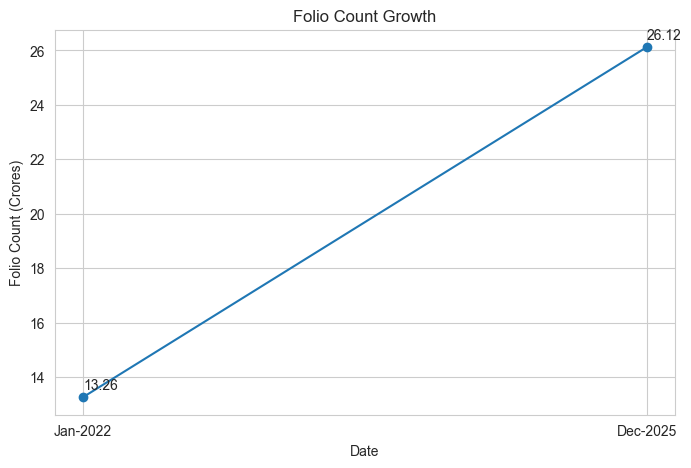

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(

    folio_df["Date"],

    folio_df["Folio_Count_Cr"],

    marker='o'

)

plt.title("Folio Count Growth")

plt.xlabel("Date")

plt.ylabel("Folio Count (Crores)")

for i,v in enumerate(folio_df["Folio_Count_Cr"]):

    plt.text(i,v+0.3,str(v))

plt.grid(True)

plt.show()

In [41]:
plt.savefig(
    "../reports/folio_growth.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

TASK 8 : NAV Return Correlation Matrix

In [43]:
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [44]:
corr = performance[
[
"return_1yr_pct",

"return_3yr_pct",

"return_5yr_pct",

"alpha",

"beta",

"sharpe_ratio"

]
].corr()

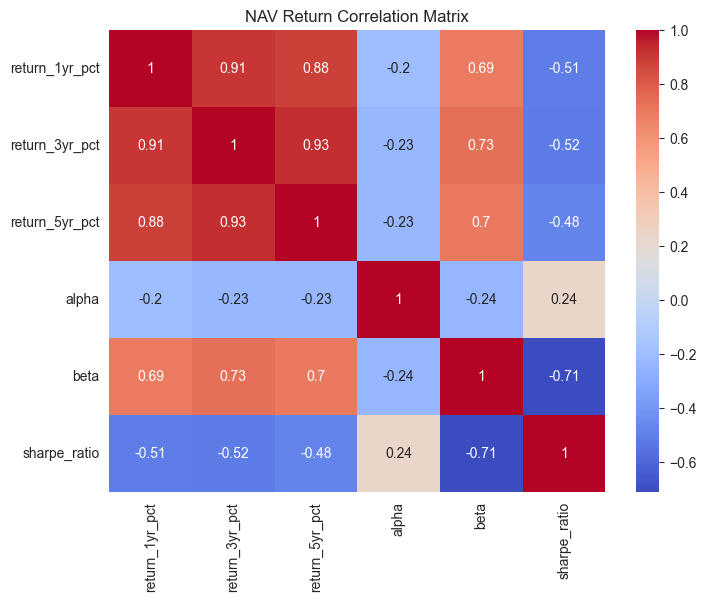

In [45]:
plt.figure(figsize=(8,6))

sns.heatmap(

corr,

annot=True,

cmap="coolwarm"

)

plt.title("NAV Return Correlation Matrix")

plt.show()

In [46]:
plt.savefig(
"../reports/correlation_matrix.png",
bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

TASK 9 : Sector Allocation Donut Chart

In [47]:
holdings = pd.read_csv("../data/raw/portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [48]:
holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [49]:
sector_weight = holdings.groupby(
    "sector"
)["weight_pct"].sum().reset_index()

In [50]:
import plotly.express as px

fig = px.pie(
    sector_weight,

    names="sector",

    values="weight_pct",

    hole=0.5,

    title="Sector Allocation Donut Chart"
)

fig.show()

In [51]:
fig.write_image(
"../reports/sector_allocation.png"
)

Finding 1
NAV values showed a steady upward trend from 2022 to 2026 across most schemes.
Finding 2
SBI Mutual Fund dominates total AUM among all fund houses.
Finding 3
Monthly SIP inflows remained consistently high with an upward trend.
Finding 4
Large Cap funds account for a major share of investor preference.
Finding 5
Expense ratios for most schemes remain within the 0.1%–2.5% range.
Finding 6
Tier 1/T30 cities contribute the majority of investments.
Finding 7
Male investors constitute a larger share of the investor base.
Finding 8
The folio count nearly doubled from 13.26 Cr to 26.12 Cr.
Finding 9
Technology and Financial sectors dominate portfolio allocations.
Finding 10
Risk and return metrics exhibit significant correlation across schemes.